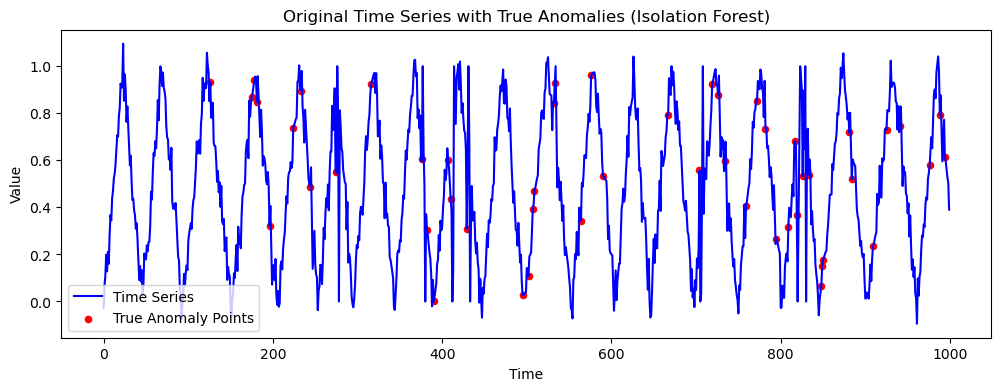

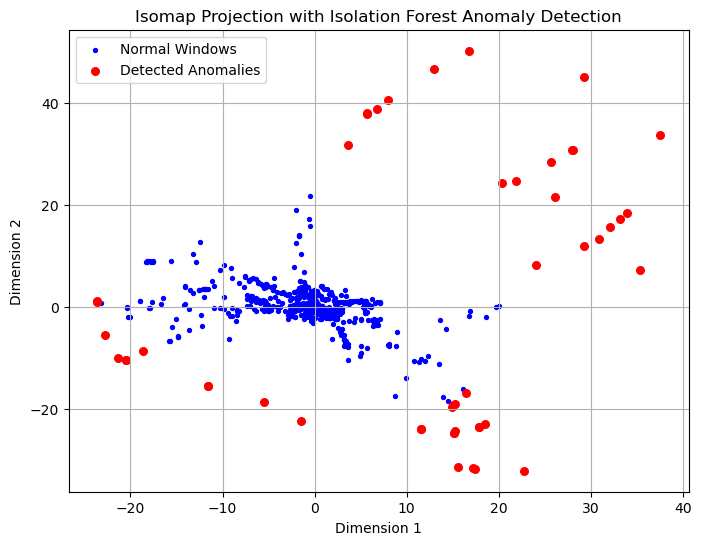

Number of detected anomaly windows: 49


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from sklearn.manifold import Isomap
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA

# 產生變周期 triangle wave 並注入異常
def generate_variable_triangle_wave(n_samples=1000, cycle_length_range=(40, 60), noise=0.05, anomaly_ratio=0.05):
    np.random.seed(42)
    t = np.arange(n_samples)
    data = np.zeros(n_samples)
    i = 0
    while i < n_samples:
        cycle_length = np.random.randint(cycle_length_range[0], cycle_length_range[1])
        half = cycle_length // 2
        cycle = np.concatenate((np.linspace(0, 1, half, endpoint=False),
                                np.linspace(1, 0, cycle_length - half)))
        cycle += np.random.normal(0, noise, size=cycle.shape)
        end_idx = min(i + cycle_length, n_samples)
        data[i:end_idx] = cycle[:end_idx - i]
        i += cycle_length

    # 注入異常（pattern mutation）
    n_anomalies = int(n_samples * anomaly_ratio)
    anomaly_indices = np.random.choice(n_samples, n_anomalies, replace=False)
    
    for idx in anomaly_indices:
        end_idx = min(idx + 5, n_samples)
        segment = data[idx:end_idx].copy()
        
        mutation_type = np.random.choice(["smoothing", "sharpening", "gradient_shift", "local_perturbation"])
        
        if mutation_type == "smoothing":
            segment = gaussian_filter1d(segment, sigma=2.0)
        elif mutation_type == "sharpening":
            segment = np.interp(np.linspace(0, 1, len(segment)), 
                                [0, 0.3, 0.7, 1], 
                                [segment[0], segment[0] + 0.1, segment[-1] - 0.1, segment[-1]])
        elif mutation_type == "gradient_shift":
            segment = np.cumsum(segment - np.mean(segment))
            segment = (segment - np.min(segment)) / (np.max(segment) - np.min(segment) + 1e-6)
        elif mutation_type == "local_perturbation":
            perturbation = np.sin(np.linspace(0, np.pi * 2, len(segment))) * np.random.uniform(0.02, 0.05)
            segment += perturbation

        segment = np.clip(segment, 0, 1)
        data[idx:end_idx] = segment
    
    return t, data, anomaly_indices

# 滑動視窗處理
def sliding_window(data, window_size=30, step=1):
    windows = []
    indices = []
    for i in range(0, len(data) - window_size + 1, step):
        windows.append(data[i:i+window_size])
        indices.append(i + window_size // 2)
    return np.array(windows), np.array(indices)

# 計算分層梯度直方圖特徵
def compute_pyramidal_gradient_histograms(windows, n_bins=10, levels=3):
    features = []
    for window in windows:
        grad = np.diff(window)
        level_features = []
        for level in range(levels):
            sub_window_size = len(grad) // (2 ** level)
            for i in range(2 ** level):
                sub_window = grad[i * sub_window_size:(i + 1) * sub_window_size]
                hist, _ = np.histogram(sub_window, bins=n_bins, range=(-1, 1), density=True)
                level_features.extend(hist)
        features.append(level_features)
    return np.array(features)

# 主函數
from sklearn.ensemble import IsolationForest

def main():
    # 產生資料
    n_samples = 1000
    t, data, true_anomaly_indices = generate_variable_triangle_wave(n_samples=n_samples, anomaly_ratio=0.05)
    
    # 提取滑動視窗
    window_size = 30
    windows, window_indices = sliding_window(data, window_size=window_size, step=1)
    
    # 計算分層梯度直方圖特徵
    pyramidal_hist_features = compute_pyramidal_gradient_histograms(windows, n_bins=10, levels=3)
    
    # 標準化特徵
    scaler_feat = StandardScaler()
    features_std = scaler_feat.fit_transform(pyramidal_hist_features)
    
    # 用 Isomap 進行降維
    isomap = Isomap(n_neighbors=10, n_components=2)
    latent_features = isomap.fit_transform(features_std)
    
    # 用 Isolation Forest 進行異常檢測
    iso_forest = IsolationForest(contamination=0.05, random_state=42)
    iso_forest.fit(latent_features)
    preds = iso_forest.predict(latent_features)
    detected_anomaly_mask = preds == -1
    
    # 視覺化原始時間序列
    plt.figure(figsize=(12,4))
    plt.plot(t, data, label="Time Series", color="blue")
    plt.scatter(t[true_anomaly_indices], data[true_anomaly_indices], color='red', s=20, label="True Anomaly Points")
    # plt.scatter(t[window_indices], data[window_indices], color='green', s=10, label="Window Centers")
    plt.title("Original Time Series with True Anomalies (Isolation Forest)")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.show()
    
    # 視覺化 Isomap 映射後的特徵空間
    plt.figure(figsize=(8,6))
    plt.scatter(latent_features[:, 0], latent_features[:, 1], color='blue', s=8, label="Normal Windows")
    plt.scatter(latent_features[detected_anomaly_mask, 0], latent_features[detected_anomaly_mask, 1], 
                color='red', s=30, label="Detected Anomalies")
    plt.title("Isomap Projection with Isolation Forest Anomaly Detection")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # 統計檢測結果
    print("Number of detected anomaly windows:", np.sum(detected_anomaly_mask))

if __name__ == "__main__":
    main()


